In [1]:
import sys
from pathlib import Path

# The notebooks are run from notebooks/, so the project root has to be on the path
# before any src.* import.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib

matplotlib.use("Agg")  # headless: the notebooks are executed in CI as well as by hand
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.reporting import configure_fonts

configure_fonts()  # CJK labels in charts render as boxes without this
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)


# 01 — Exploratory analysis of the ledger

Before any audit procedure runs, the population has to be understood. This notebook
establishes the shape of the ledger — how many vouchers, how much value, where the
value concentrates, and when postings happen — because every threshold in the rule
engine is a statement about what "normal" looks like.

Everything here reads the pipeline's own output. Run `python src/run_pipeline.py`
first.

**Note on labels.** The `anomaly_label` and `anomaly_type` columns are the injected
ground truth. This notebook uses them only where it says so explicitly, to describe
the benchmark. The dashboard never sees them.


In [2]:
scored = pd.read_parquet(PROJECT_ROOT / "data/processed/transactions_scored.parquet")
summary = json.loads((PROJECT_ROOT / "outputs/reports/audit_summary.json").read_text())

population = summary["population"]
print(f"vouchers          {len(scored):,}")
print(f"total value       CNY {scored['debit_amount'].sum():,.0f}")
print(f"period            {scored['transaction_date'].min():%Y-%m-%d} -> {scored['transaction_date'].max():%Y-%m-%d}")
print(f"vendors           {scored['vendor_id'].nunique():,}")
print(f"accounts          {scored['account_code'].nunique():,}")
print(f"employees         {scored['employee_id'].nunique():,}")


vouchers          30,128
total value       CNY 4,443,451,722
period            2024-01-01 -> 2026-01-03
vendors           409
accounts          18
employees         140


## 1. How is value distributed?

Ledger amounts are log-normally distributed, and that single fact is why the Benford analysis in notebook 02 is meaningful rather than decorative. A uniformly distributed ledger would fail Benford's Law for entirely innocent reasons.

orders of magnitude spanned (P1-P99): 3.47


,CNY
count,30128.0
mean,147485.784707
std,290282.497809
min,175.0
50%,39377.46
90%,408268.206
95%,690245.05
99%,1439796.0196
99.9%,2250000.0
max,3750000.0


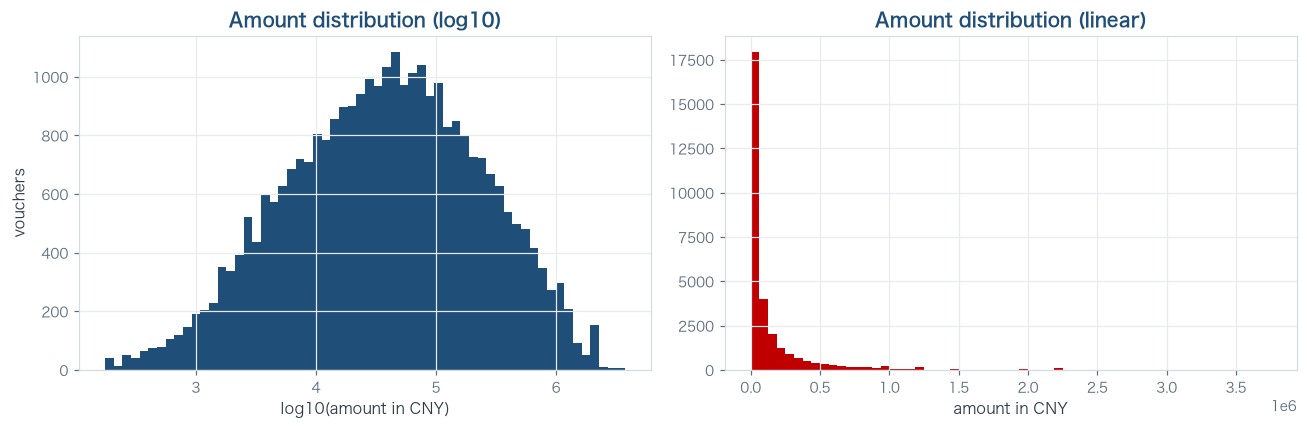

In [3]:
amounts = scored["debit_amount"]

display(amounts.describe(percentiles=[0.5, 0.9, 0.95, 0.99, 0.999]).to_frame("CNY"))

figure, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(np.log10(amounts[amounts > 0]), bins=60, color="#1F4E79")
axes[0].set_title("Amount distribution (log10)")
axes[0].set_xlabel("log10(amount in CNY)")
axes[0].set_ylabel("vouchers")

axes[1].hist(amounts, bins=60, color="#C00000")
axes[1].set_title("Amount distribution (linear)")
axes[1].set_xlabel("amount in CNY")
plt.tight_layout()
plt.show()

# The spread of the distribution is what makes the digit tests usable.
print(f"orders of magnitude spanned (P1-P99): "
      f"{np.log10(amounts.quantile(0.99)) - np.log10(max(amounts.quantile(0.01), 1)):.2f}")


## 2. Where does the value sit?

A small number of accounts carry most of the value. Audit effort follows materiality, so this ordering matters more than the voucher counts.

In [4]:
by_account = (
    scored.groupby(["account_code", "account_name"], observed=True)
    .agg(vouchers=("transaction_id", "count"), value=("debit_amount", "sum"))
    .reset_index()
    .sort_values("value", ascending=False)
)
by_account["share_of_value"] = by_account["value"] / by_account["value"].sum()
by_account["cumulative_share"] = by_account["share_of_value"].cumsum()

display(by_account.head(10).style.format({"value": "{:,.0f}", "share_of_value": "{:.2%}", "cumulative_share": "{:.1%}"}))

top_five = by_account.head(5)["share_of_value"].sum()
print(f"the five largest accounts carry {top_five:.1%} of the ledger's value")


the five largest accounts carry 85.4% of the ledger's value


,account_code,account_name,vouchers,value,share_of_value,cumulative_share
0,1122,应收账款 Accounts receivable,4404,"1,119,018,141",25.22%,25.2%
6,2202,应付账款 Accounts payable,6100,"954,609,520",21.51%,46.7%
8,2211,应付职工薪酬 Payroll payable,1453,"848,318,887",19.12%,65.8%
2,1403,原材料 Raw materials,4795,"568,120,103",12.80%,78.6%
4,1601,固定资产 Fixed assets,614,"300,617,371",6.77%,85.4%
11,6401,主营业务成本 Cost of sales,2353,"231,818,615",5.22%,90.6%
16,660205,管理费用-咨询费 Consulting fees,1202,"171,110,333",3.86%,94.5%
9,2221,应交税费 Taxes payable,588,"131,379,667",2.96%,97.5%
12,660201,管理费用-差旅费 Travel expenses,3353,"47,875,696",1.08%,98.5%
13,660202,管理费用-办公费 Office expenses,2748,"26,007,322",0.59%,99.1%


## 3. When do postings happen?

Month-end clustering is a classic journal-entry risk: it is where manual adjustments concentrate, and it is why the weekend/holiday rule has a population to work with at all.

postings by weekday of the transaction date:
  Mon  39.20%  ##############################################################################
  Tue  16.07%  ################################
  Wed  14.76%  #############################
  Thu  14.36%  ############################
  Fri  13.34%  ##########################
  Sat   1.40%  ##
  Sun   0.88%  #

weekend share of the ledger: 2.27%
postings on day 25 or later: 20.29% of the ledger


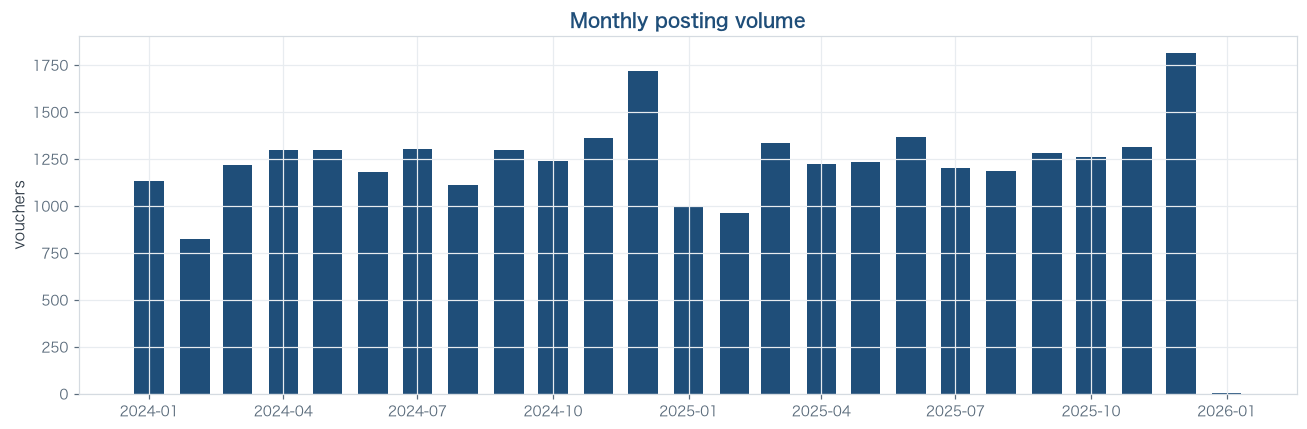

In [5]:
scored["transaction_date"] = pd.to_datetime(scored["transaction_date"])

monthly = (
    scored.set_index("transaction_date")
    .resample("MS")
    .agg(vouchers=("transaction_id", "count"), value=("debit_amount", "sum"))
)

figure, axis = plt.subplots(figsize=(12, 4))
axis.bar(monthly.index, monthly["vouchers"], width=20, color="#1F4E79", label="vouchers")
axis.set_ylabel("vouchers")
axis.set_title("Monthly posting volume")
plt.tight_layout()
plt.show()

weekday = scored["transaction_date"].dt.dayofweek
names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
print("postings by weekday of the transaction date:")
for index, name in enumerate(names):
    share = (weekday == index).mean()
    print(f"  {name}  {share:6.2%}  {'#' * int(share * 200)}")
print(f"\nweekend share of the ledger: {(weekday >= 5).mean():.2%}")

day_of_month = scored["transaction_date"].dt.day
month_end = (day_of_month >= 25).mean()
print(f"postings on day 25 or later: {month_end:.2%} of the ledger")


## 4. Vendor concentration

How concentrated is the supplier base? A concentrated base changes the audit approach: the fewer the relationships, the more each one matters and the less a sample of transactions tells you.

In [6]:
by_vendor = (
    scored.groupby("vendor_name", observed=True)
    .agg(payments=("transaction_id", "count"), value=("debit_amount", "sum"))
    .sort_values("value", ascending=False)
)
total_value = by_vendor["value"].sum()
print(f"top 10 vendors  {by_vendor.head(10)['value'].sum() / total_value:6.2%} of value")
print(f"top 50 vendors  {by_vendor.head(50)['value'].sum() / total_value:6.2%} of value")
print(f"vendors         {len(by_vendor):,}")
print()
display(by_vendor.head(10).style.format({"value": "{:,.0f}"}))


top 10 vendors   7.09% of value
top 50 vendors  25.57% of value
vendors         383



,payments,value
vendor_name,,
Mingda Technology Group,144,"17,646,698"
Zhongtai Services Holdings,120,"16,419,036"
"Kaiyuan Electronics (Beijing) Co., Ltd.",119,"14,850,971"
"Xinrun Packaging Co., Ltd.",104,"14,572,995"
"Orient Industrial (Shanghai) Co., Ltd.",145,"14,343,922"
Union Engineering Holdings,108,"14,170,717"
"Ruixin Industrial (Beijing) Co., Ltd.",113,"13,529,837"
"Qianhai Services (Guangzhou) Co., Ltd.",118,"12,345,371"
"Longhe Trading (Shanghai) Co., Ltd.",116,"11,769,667"


## 5. Data quality is a finding

The extract arrives dirty on purpose. What matters is that the cleaner *reports* every issue it finds, including the ones it deliberately does not repair.

In [7]:
quality = json.loads((PROJECT_ROOT / "outputs/reports/data_quality_report.json").read_text())

issues = pd.DataFrame(
    [
        ("Duplicate rows", quality["duplicates_removed"], "removed"),
        ("Invalid transaction dates", quality["invalid_date_rows"], "row dropped"),
        ("Invalid posting dates", quality["invalid_posting_dates"], "repaired"),
        ("Invalid amounts", quality["invalid_amount_rows"], "row dropped"),
        ("Unbalanced vouchers", quality["unbalanced_rows"], "flagged, kept"),
        ("Orphan vendors", quality["orphan_vendor_rows"], "flagged, kept"),
        ("Account name mismatches", quality["account_name_mismatches"], "repaired"),
        ("Currency codes normalised", quality["currency_normalised_rows"], "normalised"),
    ],
    columns=["Issue", "Count", "Action"],
)

print(f"raw rows {quality['raw_rows']:,} -> clean rows {quality['clean_rows']:,}")
print(f"total issues {quality['total_issues']} = {quality['issue_rate_pct']}% of the raw extract")
print()
display(issues.style.hide(axis="index"))

print("The repairs, as logged by the cleaner:")
for line in quality["repair_log"]:
    print(f"  - {line}")


raw rows 30,223 -> clean rows 30,128
total issues 285 = 0.943% of the raw extract

The repairs, as logged by the cleaner:
  - Normalised 34 messy currency codes to ISO 4217.
  - Rebuilt 45 posting dates from the transaction date.
  - Removed 36 vouchers with a missing, zero or negative amount.
  - Removed 59 exact duplicate rows.
  - Repaired 30 account names from the chart of accounts.
  - Flagged 36 vouchers referencing an unknown vendor (master-data gap).
  - Flagged 45 unbalanced vouchers (debit leg != credit leg).


Issue,Count,Action
Duplicate rows,59,removed
Invalid transaction dates,45,row dropped
Invalid posting dates,45,repaired
Invalid amounts,36,row dropped
Unbalanced vouchers,45,"flagged, kept"
Orphan vendors,36,"flagged, kept"
Account name mismatches,30,repaired
Currency codes normalised,34,normalised


## 6. The triage, before any analysis

The composite risk score has already been computed by the pipeline. This is the shape of its output — and the shape is the point: a well-calibrated triage puts almost everything in the bottom band.

average risk score across the population: 14.64
High + Critical: 255 vouchers (0.846%) carrying CNY 267,015,002


,vouchers,value,share_of_vouchers,share_of_value
Low,"28,261","3,453,451,915",93.80%,77.72%
Medium,"1,612","722,984,805",5.35%,16.27%
High,254,"265,765,002",0.84%,5.98%
Critical,1,"1,250,000",0.00%,0.03%


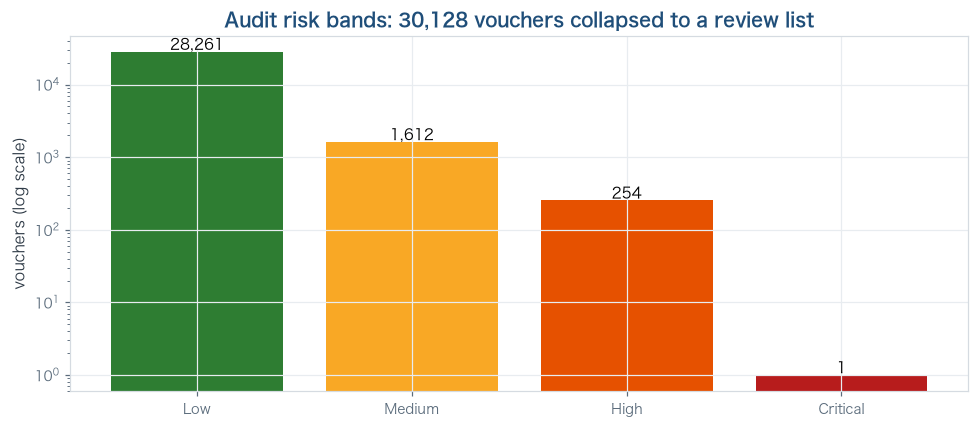

In [8]:
triage = summary["triage"]
bands = pd.DataFrame(
    {
        "vouchers": pd.Series(triage["risk_level_counts"]),
        "value": pd.Series(triage["risk_level_amounts"]),
    }
).reindex(["Low", "Medium", "High", "Critical"])

bands["share_of_vouchers"] = bands["vouchers"] / bands["vouchers"].sum()
bands["share_of_value"] = bands["value"] / bands["value"].sum()
display(bands.style.format({"vouchers": "{:,.0f}", "value": "{:,.0f}",
                            "share_of_vouchers": "{:.2%}", "share_of_value": "{:.2%}"}))

figure, axis = plt.subplots(figsize=(9, 4))
colours = ["#2E7D32", "#F9A825", "#E65100", "#B71C1C"]
axis.bar(bands.index, bands["vouchers"], color=colours)
axis.set_yscale("log")
axis.set_ylabel("vouchers (log scale)")
axis.set_title("Audit risk bands: 30,128 vouchers collapsed to a review list")
for position, count in enumerate(bands["vouchers"]):
    axis.text(position, count, f"{count:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

print(f"average risk score across the population: {triage['average_risk_score']}")
print(f"High + Critical: {triage['high_or_critical']:,} vouchers "
      f"({triage['high_or_critical_pct']}%) carrying CNY {triage['high_or_critical_amount']:,.0f}")


## What this establishes

- **30,128 vouchers, CNY 4.44B** over two years — far more than any team can read, so
  the deliverable is a ranking, not a conclusion.
- **Amounts span several orders of magnitude and are log-normally distributed**, which
  is what makes the digit tests in notebook 02 legitimate.
- **Postings cluster at month-end**, and weekends are only 2.3% of the ledger because
  the generator models a working calendar — a naive uniform sampler would produce 28%
  and make the weekend rule meaningless.
- **The top five accounts carry most of the value.** Audit effort follows materiality.
- **The extract carries 285 quality issues (0.94%)**, and two of them — unbalanced
  vouchers and orphan vendors — are themselves findings, which is why the cleaner
  flags rather than deletes.
- **The triage puts 93.8% of the population in the Low band**, which is what a
  discriminating score looks like.
